### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [351]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [352]:
data = pd.read_csv('data/coupons.csv')

In [353]:
data = data.rename(columns={'passanger': 'passenger'})

print(data['toCoupon_GEQ25min'])

print("-" * 50)
# print(data['occupation'].value_counts())
print(data['age'].value_counts())


g = """
--- User attributes ---
gender: male or female
maritalStatus: marital status
has_children: whether the customer has children
education: education level
age: customer's age
occupation: customer's occupation
income: customer's income
Bar: How often the customer goes to a bar per month
CoffeeHouse: How often the customer goes to a coffee house
CarryAway: How often the customer goes to a carry out place
RestaurantLessThan20: How often the customer goes to a restaurant under $20
Restaurant20To50: How often the customer goes to a restaurant between $20 and $50

--- Context ---
destination: where the customer is going
passenger: who the passenger is
weather: what the weather is like
temperature: temperature in Fahrenheit
time: time of day when the coupon is issued
direction_same: 1 if the customer is going in the same direction as the coupon, 0 if opposite
direction_opp: 1 if the customer is going in the opposite direction as the coupon, 0 if same

--- Coupon details ---
coupon: type of coupon. Bar, CoffeeHouse, CarryOut, RestaurantLessThan20, Restaurant20To50
expiration: how long until the coupon expires
toCoupon_GEQ5min: 1 if the coupon venue is more than 5 minutes away from the driver's current location.
toCoupon_GEQ15min: 1 if the coupon venue is more than 15 minutes away from the driver's current location.
toCoupon_GEQ25min: 1 if the coupon venue is more than 25 minutes away from the driver's current location.

--- Result ---
Y: Whether the customer accepted the coupon

"""

0        0
1        0
2        0
3        0
4        0
        ..
12679    0
12680    0
12681    0
12682    1
12683    0
Name: toCoupon_GEQ25min, Length: 12684, dtype: int64
--------------------------------------------------
age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64


2. Investigate the dataset for missing or problematic data.

In [354]:
len(data) # 12684
data.isna().sum()

data.info()

data['age'].value_counts()


<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passenger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [355]:
# Remove the car column as it has 12576 NaN values out of 12684.
data = data.drop(columns=['car'])

# Drop the remaining 794 rows. We are removing about 6.31% of the data, so this has no impact.
data = data.dropna(subset=['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50'])


4. What proportion of the total observations chose to accept the coupon?



In [356]:
# Proportion of customers who accepted the coupon
def acceptance_rate(df):
    if len(df) == 0:
        return 0.0
    percentage_accepted = df['Y'].value_counts(normalize=True)
    return percentage_accepted[1] * 100

def acceptance_rate_str(df):
    v = acceptance_rate(df)
    return f"{v:.2f}%"


print(f"Proportion of customers who accepted the coupon: {acceptance_rate_str(data)}")


Proportion of customers who accepted the coupon: 56.93%


5. Use a bar plot to visualize the `coupon` column.

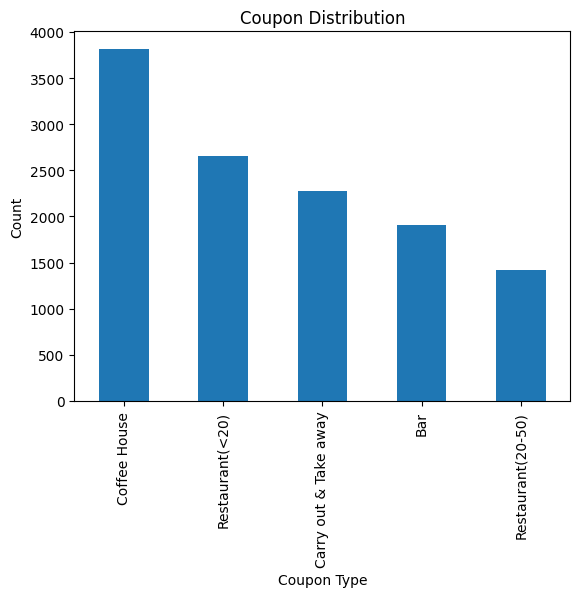

In [357]:
data['coupon'].value_counts().plot(kind='bar')
plt.title('Coupon Distribution')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.show()

6. Use a histogram to visualize the temperature column.

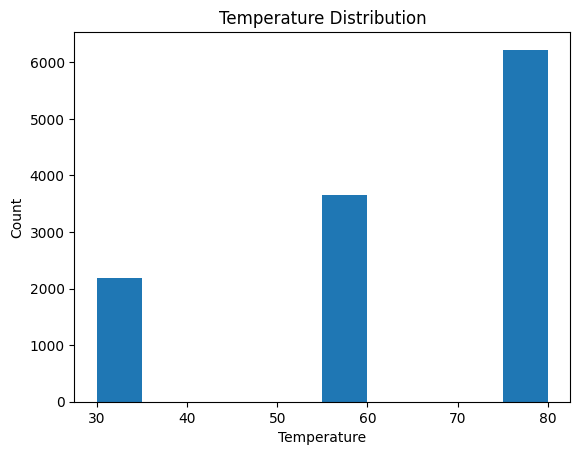

In [358]:
data['temperature'].plot(kind="hist")
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()


**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [359]:
df_bar = data.query("coupon == 'Bar'")
len(df_bar)

1913

2. What proportion of bar coupons were accepted?


In [360]:
print(f"Proportion of customers who accepted the Bar coupon: {acceptance_rate_str(df_bar)}")

Proportion of customers who accepted the Bar coupon: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [361]:
list_3_or_few = ['never', 'less1', '1~3']
df_bar['Bar_3_or_few'] = df_bar.apply(lambda x: 1  if x['Bar'] in list_3_or_few else 0, axis=1)
df_bar['Bar_more_than_3'] = df_bar.apply(lambda x: 1  if x['Bar'] not in list_3_or_few else 0, axis=1)

# print(df_bar[['Bar_3_or_few', 'Bar_more_than_3']])
# print(df_bar['Bar_3_or_few'].value_counts())
# print(df_bar['Bar_more_than_3'].value_counts())

print(f"Acceptance rate of Bar coupon who went to a bar 3 or fewer times: {acceptance_rate_str(df_bar.query('Bar_3_or_few == 1'))}")
print(f"Acceptance rate of Bar coupon who went more than 3 times:  {acceptance_rate_str(df_bar.query('Bar_more_than_3 == 1'))}")

Acceptance rate of Bar coupon who went to a bar 3 or fewer times: 37.27%
Acceptance rate of Bar coupon who went more than 3 times:  76.17%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [362]:
age_less_25 = ['21', 'below21']
bar_less_than_1 = ['never', 'less1']

drivers_25plus_bar_once_atleast = df_bar.query("age not in @age_less_25 and Bar not in @bar_less_than_1")
not_drivers_25plus_bar_once_atleast = df_bar[~df_bar.index.isin(drivers_25plus_bar_once_atleast.index)]


print(f"Acceptance rate: bar visitors >1/month, age >25: {acceptance_rate_str(drivers_25plus_bar_once_atleast)}")
print(f"Acceptance rate for all other drivers:  {acceptance_rate_str(not_drivers_25plus_bar_once_atleast)}")


Acceptance rate: bar visitors >1/month, age >25: 68.98%
Acceptance rate for all other drivers:  33.77%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [363]:

occupations = ['Farming Fishing & Forestry']

acceptance_bar_freq_no_kids_non_farm = df_bar.query('Bar not in @bar_less_than_1 and occupation not in @occupations and passenger != "Kid(s)"')
not_acceptance_bar_freq_no_kids_non_farm = df_bar[~df_bar.index.isin(acceptance_bar_freq_no_kids_non_farm.index)]

print(f"Acceptance rate: bar visitors >1/month, no kid passengers, non-farming occupations: {acceptance_rate_str(acceptance_bar_freq_no_kids_non_farm)}")
print(f"Acceptance rate of other drivers: {acceptance_rate_str(not_acceptance_bar_freq_no_kids_non_farm)}")

Acceptance rate: bar visitors >1/month, no kid passengers, non-farming occupations: 70.94%
Acceptance rate of other drivers: 29.79%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [364]:
acceptance_bar_freq_no_kids_non_farm = df_bar.query(
    "Bar not in @bar_less_than_1 and "
    "maritalStatus != 'Widowed' and "
    "passenger != 'Kid(s)'"
)
print(f"Acceptance rate: bar visitors >1/month, no kid passengers, not widowed: {acceptance_rate_str(acceptance_bar_freq_no_kids_non_farm)}")

age_less_30 = ['21', 'below21', '26']
acceptance_bar_freq_under_30 = df_bar.query(
    "Bar not in @bar_less_than_1 and "
    "age in @age_less_30"
)
print(f"Acceptance rate: bar visitors >1/month, age <30: {acceptance_rate_str(acceptance_bar_freq_under_30)}")

rest_visit_4plus = ['4~8', 'gt8']
income_less_50k = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']
print(f"Val = {df_bar['income'].value_counts()}")

acceptance_budget_dining_under_50k = df_bar.query(
    "RestaurantLessThan20 in @rest_visit_4plus and "
    "income in @income_less_50k"
)
print(len(acceptance_budget_dining_under_50k))
print(f"Acceptance rate: cheap restaurant visitors >4/month, income <$50K: {acceptance_rate_str(acceptance_budget_dining_under_50k)}")


Acceptance rate: bar visitors >1/month, no kid passengers, not widowed: 70.94%
Acceptance rate: bar visitors >1/month, age <30: 71.95%
Val = income
$25000 - $37499     300
$100000 or More     282
$12500 - $24999     271
$50000 - $62499     249
$37500 - $49999     247
Less than $12500    159
$75000 - $87499     143
$87500 - $99999     133
$62500 - $74999     129
Name: count, dtype: int64
333
Acceptance rate: cheap restaurant visitors >4/month, income <$50K: 45.65%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  